# Steel Industry Energy Consumption Analysis
  Name: Murtaza Khalid 
  
Objective: Deep EDA and Baseline Regression Modeling on Steel Plant Energy Dataset.



## 1. Libraries Import

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load and Examine Dataset

In [3]:
# Load the dataset
df = pd.read_csv('Steel_industry_data.csv')

# Display the first 5 rows
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [4]:
# Check dataset structure and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  str    
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  str    
 9   Day_of_week                           35040 non-null  str    
 10  Load_Type                             35040 non-null  str    
dtypes: float64(6), int64(1), s

## 3. Date Feature Engineering
Converting the 'date' column to datetime format and extracting temporal features.

In [5]:
# 'dayfirst=True
# 'format="mixed"' 
df['date'] = pd.to_datetime(df['date'], dayfirst=True, format='mixed')

#  features extract 
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month
df['is_weekday'] = df['date'].dt.dayofweek.apply(lambda x: 1 if x < 5 else 0)

# Verify 
print("Date processing successful!")
df[['date', 'hour', 'day_of_week', 'is_weekday']].head()

Date processing successful!


,date,hour,day_of_week,is_weekday
0,2018-01-01 00:15:00,0,Monday,1
1,2018-01-01 00:30:00,0,Monday,1
2,2018-01-01 00:45:00,0,Monday,1
3,2018-01-01 01:00:00,1,Monday,1
4,2018-01-01 01:15:00,1,Monday,1


In [6]:
df.describe()



,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,hour,month,is_weekday
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000
mean,2018-07-02 11:52:30,27.386892,13.035384,3.870949,0.011524,80.578056,84.367870,42750.000000,11.500000,6.526027,0.715068
min,2018-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2018-04-02 05:56:15,3.200000,2.300000,0.000000,0.000000,63.320000,99.700000,21375.000000,5.750000,4.000000,0.000000
50%,2018-07-02 11:52:30,4.570000,5.000000,0.000000,0.000000,87.960000,100.000000,42750.000000,11.500000,7.000000,1.000000
75%,2018-10-01 17:48:45,51.237500,22.640000,2.090000,0.020000,99.022500,100.000000,64125.000000,17.250000,10.000000,1.000000
max,2018-12-31 23:45:00,157.180000,96.910000,27.760000,0.070000,100.000000,100.000000,85500.000000,23.000000,12.000000,1.000000
std,NaN,33.444380,16.306000,7.424463,0.016151,18.921322,30.456535,24940.534317,6.922285,3.447901,0.451388


 Power Factor Ratio & High Load
Creating new features: 
1. Power Factor Ratio = Leading / Lagging
2. High Load = Binary flag (1 if Usage > 75th percentile)

In [7]:
# 1. Power Factor Ratio
df['Power_Factor_Ratio'] = df['Leading_Current_Power_Factor'] / df['Lagging_Current_Power_Factor']

# 2. High Load Feature
threshold = df['Usage_kWh'].quantile(0.75)
df['High_Load'] = df['Usage_kWh'].apply(lambda x: 1 if x > threshold else 0)

print("New features 'Power_Factor_Ratio' and 'High_Load' created successfully.")

New features 'Power_Factor_Ratio' and 'High_Load' created successfully.


## 5. Outlier Detection (IQR Method)
Visualizing outliers in 'Usage_kWh' to identify extreme energy consumption readings.

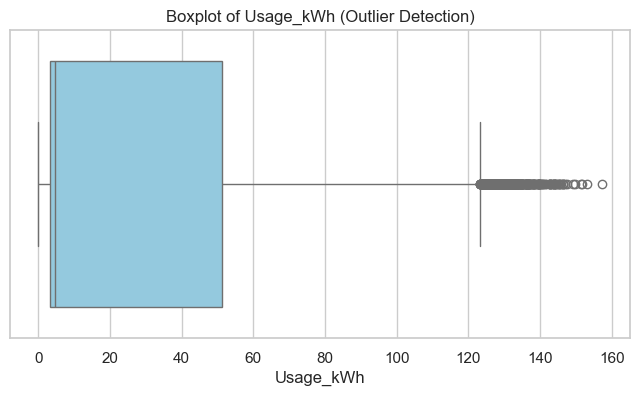

IQR range: 48.04


In [8]:
# IQR Calculation
Q1 = df['Usage_kWh'].quantile(0.25)
Q3 = df['Usage_kWh'].quantile(0.75)
IQR = Q3 - Q1

# Boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Usage_kWh'], color='skyblue')
plt.title('Boxplot of Usage_kWh (Outlier Detection)')
plt.show()

print(f"IQR range: {IQR:.2f}")

## 6. Correlation Heatmap
Identifying the top features that influence energy consumption.


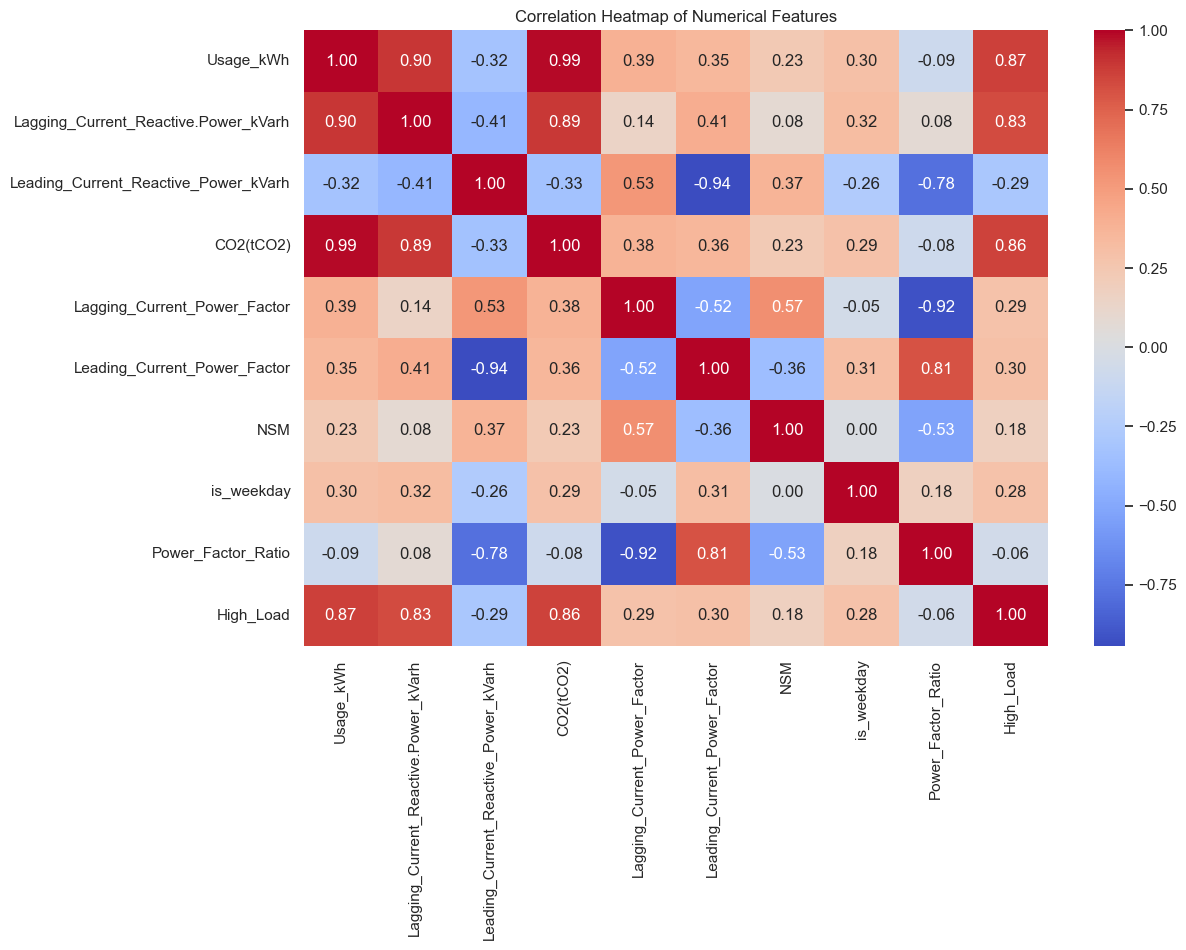

In [9]:
# Selecting only numerical columns for correlation
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numerical_cols].corr()

# Plotting heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## 7. Average Energy Consumption by Load Type
Analyzing how different load types (Light, Medium, Maximum) affect overall energy usage.

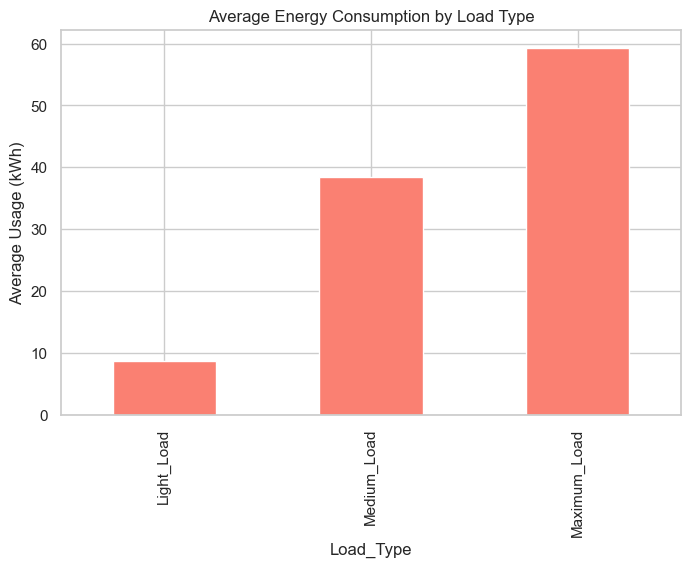

In [10]:
# Grouping by Load_Type and calculating mean Usage_kWh
load_usage = df.groupby('Load_Type')['Usage_kWh'].mean().sort_values()

# Bar Chart
plt.figure(figsize=(8, 5))
load_usage.plot(kind='bar', color='salmon')
plt.title('Average Energy Consumption by Load Type')
plt.ylabel('Average Usage (kWh)')
plt.show()

## 8. Average Energy Usage by Hour of Day
Identifying the hourly energy patterns in the steel manufacturing plant.

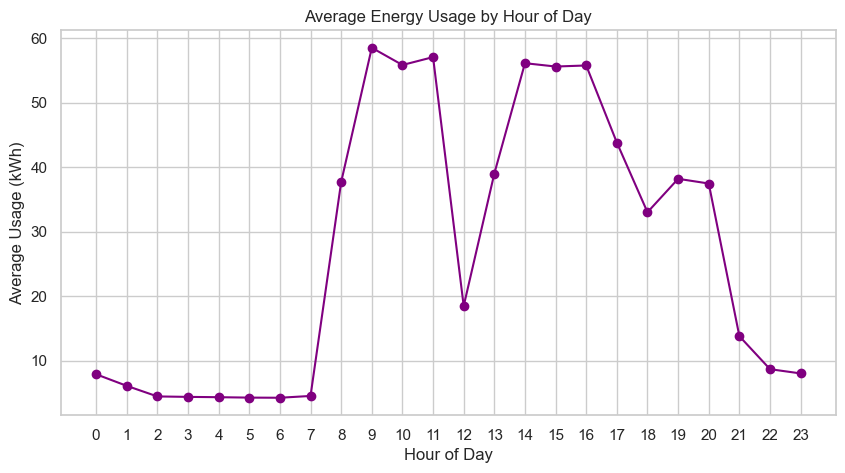

In [11]:
# Grouping by hour and calculating mean
hourly_usage = df.groupby('hour')['Usage_kWh'].mean()

# Line Chart
plt.figure(figsize=(10, 5))
hourly_usage.plot(kind='line', marker='o', color='purple')
plt.title('Average Energy Usage by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Usage (kWh)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

## 9. EDA Summary & Insights

After conducting a deep exploratory data analysis on the Steel Industry Energy Consumption dataset, we have uncovered several critical patterns regarding industrial energy usage.

**Data Quality & Preprocessing:**
The dataset was found to be highly reliable with no missing values. Through feature engineering, we successfully converted the timestamp into meaningful temporal features (hour, day, month) and created custom metrics like 'Power_Factor_Ratio' and a 'High_Load' binary indicator. 

**Key Correlation Findings:**
The correlation heatmap revealed a near-perfect positive correlation between 'Usage_kWh' and 'CO2(tCO2)' (0.99), suggesting that energy intensity is directly proportional to carbon emissions in this plant. Furthermore, 'Lagging_Current_Reactive.Power_kVarh' also shows a strong positive correlation (0.90) with energy consumption.

**Observed Patterns:**
- **Load Type Impact:** Our analysis indicates that 'Maximum Load' periods correspond to the highest average energy consumption, which is expected in a manufacturing environment.
- **Hourly Trends:** The hourly line chart highlights distinct spikes in energy usage, likely correlating with shift changes and peak production hours during the day.

**Hypothesis:**
We hypothesize that the observed energy spikes are not random but are driven by industrial operational schedules and shift-based machine start-up cycles. Future models should leverage the 'hour' and 'Load_Type' features as primary predictors to optimize energy efficiency. By identifying these patterns, the facility can implement load-shifting strategies to reduce peak energy costs.

# Part 2: Baseline Regression Modeling
In this section, we prepare the dataset for machine learning, train four different regression models, and evaluate their performance to establish a baseline.

## 1. Data Preparation for Modeling



In [25]:


df_model = df.drop(columns=['date', 'High_Load'], errors='ignore')


df_model = pd.get_dummies(df_model, drop_first=True)


df_model = df_model.apply(pd.to_numeric, errors='coerce')
df_model = df_model.fillna(0)

# Verify
print("Data ready! Numeric columns shape:", df_model.shape)
print("Any string columns left?", df_model.select_dtypes(include=['object']).columns.tolist())

Data ready! Numeric columns shape: (35040, 26)
Any string columns left? []


## 2. Train-Test Split
Splitting the dataset into 80% training set and 20% testing set for model evaluation.


In [26]:
# Cell 2: Splitting
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['Usage_kWh'])
y = df_model['Usage_kWh']

# 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Split completed.")

Split completed.


## 3. Baseline Regression Modeling
Training four regression models: Linear Regression, Ridge Regression, Decision Tree, and Random Forest.


In [27]:
# Cell 3: Training and Evaluation
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({"Model": name, "RMSE": rmse, "R2": r2})
    print(f"{name} trained successfully!")

# Final Results
results_df = pd.DataFrame(results)
display(results_df)

Linear Regression trained successfully!
Ridge trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!


,Model,RMSE,R2
0,Linear Regression,4.140520,0.984918
1,Ridge,6.244464,0.965697
2,Decision Tree,1.539590,0.997915
3,Random Forest,1.029087,0.999068
